# Example: ROM for 1D heat eqaution

### Overview

This notebook demonstrates how to build end-to-end reduced-order models (ROMs) for forced 1D heat equation simulations using the `deepe2erom` package. The workflow covers data loading, preprocessing, model construction (encoder, decoder, and dynamics), and training with the package's Trainer utility.

### Dataset

Run `data_generation.py` script to generate the high-dimensional dataset. Alternatively, download the dataset directly from [here](https://ruhr-uni-bochum.sciebo.de/s/c79mWK3NityATLT) (place the `ball_in_box_data.pkl` file in the `./data/` directory relative to this notebook).

### Expected outputs

- A trained model saved under `./results_*`
- Logs of training/validation loss and model parameter counts printed in the notebook

In [1]:
import pickle
import torch
from matplotlib.font_manager import FontProperties

# Set Times font properties for publication-quality figures
times_font_path = '/usr/share/fonts/truetype/times.ttf'
try:
    times_font = FontProperties(fname=times_font_path)
    times_font_leg = FontProperties(fname=times_font_path)
except Exception as e:
    print(f"Warning: Font not found at {times_font_path} or could not be loaded. Using default font.")
    times_font = FontProperties()
    times_font_leg = FontProperties()
times_font.set_size(8)
times_font_leg.set_size(8)

# identify device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

# Load data
with open("./data/heat_equation_data.pkl", "rb") as f:
    data = pickle.load(f)

# Extract data
states, controls = data['all_T_histories'], data['all_U_histories']
print("States shape:", states.shape)
print("Controls shape:", controls.shape)

Using device: cuda
States shape: (2000, 251, 101)
Controls shape: (2000, 251, 101)


## Data pre-processing

First, we prepare sequences for ROM training. The preprocessor converts raw frames and controls into time-series sequences suitable for for training end-to-end ROMs.

The expected input shapes for the processor are:
- for 1D states: `(nb_simulations, time_steps, states_dim)`.
- for 2D states: `(nb_simulations, time_steps, nb_channels, height, width)`.
- for controls: `(nb_simulations, time_steps, control_dim)`.

`DataPreprocessor` returns:

- processed_data[`datasets`]: dict with `train`', `val`, and `test` torch Dataset objects ready for `DataLoader`.
- processed_data[`simulations`]: dict with `train`', `val`, and `test` simulations (scaled and original).
- processed_data[`metadata`].

After processing, we typically wrap datasets in `torch.utils.data.DataLoader` with a chosen `batch_size`.

In [31]:
from deepe2erom import DataConfig, DataPreprocessor
from torch.utils.data import DataLoader
import numpy as np

# Hyperparameters
lookback = 10
pred_horizon = 5

# Configure data preprocessor
config = DataConfig(
    # Data splitting
    train_split=0.5,
    val_split=0.2,
    test_split=0.3,
    
    # Sequence parameters
    lookback=lookback,             # Use 10 past time steps as input
    pred_horizon=pred_horizon,     # Predict 5 future time steps
    stride=1,                      # No skipping between sequences
    
    # Scaling
    scale_states=False,
    scale_controls=True,
    scale_states_collectively=False,         # Not relevant since scale_states=False
    scale_controls_collectively=True,        # Scale controls separately
    scaling_method="minmax",                 # Scaling method: "minmax" or "standard"
    
    # Device
    device=device
)

# Initialize data preprocessor
preprocessor = DataPreprocessor(config)

# Process data
processed_data = preprocessor.process_simulations(states, controls)

# Extract training dataset
train_dataset = processed_data['datasets']['train']
valid_dataset = processed_data['datasets']['val']

# Create DataLoaders
batch_size = 128
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
valid_loader = DataLoader(valid_dataset, batch_size=batch_size)


Scaling controls using:  minmax


### Model creation - Control-affine

Components

- Encoder: maps high-dimensional frames to a low-dimensional latent representation.
- Decoder: reconstructs high-dimensional frames from latents.
- Dynamics (control-affine): models latent evolution using a state-dependent drift and input networks.


In [3]:
# Hyperparameters
state_dim = states.shape[2]  # (nb_channels, height, width)
control_dim = controls.shape[-1]
latent_dim = 6
control_latent_dim = 6

# Encoder/Decoder Architectures
encoder_arch = [
    {"type": "Linear", "params": {"in_features": state_dim, "out_features": 64}},
    {"type": "ReLU"},
    {"type": "Linear", "params": {"in_features": 64, "out_features": 32}},
    {"type": "ReLU"},
    {"type": "Linear", "params": {"in_features": 32, "out_features": latent_dim}},
]

decoder_arch = [
    {"type": "Linear", "params": {"in_features": latent_dim, "out_features": 32}},
    {"type": "ReLU"},
    {"type": "Linear", "params": {"in_features": 32, "out_features": 64}},
    {"type": "ReLU"},
    {"type": "Linear", "params": {"in_features": 64, "out_features": state_dim}},
]

# Encoder/Decoder Architectures for Control Autoencoder
encoder_arch_control = [
    {"type": "Linear", "params": {"in_features": control_dim, "out_features": 64}},
    {"type": "ReLU"},
    {"type": "Linear", "params": {"in_features": 64, "out_features": 32}},
    {"type": "ReLU"},
    {"type": "Linear", "params": {"in_features": 32, "out_features": control_latent_dim}},
    {"type": "Sigmoid"},
]

decoder_arch_control = [
    {"type": "Linear", "params": {"in_features": control_latent_dim, "out_features": 32}},
    {"type": "ReLU"},
    {"type": "Linear", "params": {"in_features": 32, "out_features": 64}},
    {"type": "ReLU"},
    {"type": "Linear", "params": {"in_features": 64, "out_features": control_dim}},
    {"type": "Sigmoid"},
]

# Dynamics Architectures
# Input to dynamics is: latent_dim * lookback + control_dim * (lookback - 1)
dyn_input_dim = latent_dim * config.lookback + control_latent_dim * (config.lookback - 1)

drift_arch = [
    {"type": "Linear", "params": {"in_features": dyn_input_dim, "out_features": 128}},
    {"type": "ReLU"},
    {"type": "Linear", "params": {"in_features": 128, "out_features": 128}},
    {"type": "ReLU"},
    {"type": "Linear", "params": {"in_features": 128, "out_features": latent_dim}}
]

input_arch = [
    {"type": "Linear", "params": {"in_features": dyn_input_dim, "out_features": 128}},
    {"type": "ReLU"},
    {"type": "Linear", "params": {"in_features": 128, "out_features": 128}},
    {"type": "ReLU"},
    {"type": "Linear", "params": {"in_features": 128, "out_features": latent_dim*control_latent_dim}}
]

Next, we create the ROM model using the defined architectures. The `create_model` helper will wire encoder, decoder and dynamics into a single object suitable for training with the Trainer.

In [16]:
from deepe2erom import create_model

model = create_model(
    state_dim=state_dim,
    control_dim=control_dim,
    lookback=config.lookback,
    pred_horizon=config.pred_horizon,
    latent_dim=latent_dim,
    control_latent_dim=control_latent_dim,
    dynamics_type="control_affine",
    drift_arch=drift_arch,
    input_arch=input_arch,
    encoder_arch=encoder_arch,
    decoder_arch=decoder_arch,
    use_control_autoencoder=True,
    control_encoder_arch=encoder_arch_control,
    control_decoder_arch=decoder_arch_control,
    device=device,
    seed=42
)

print("Model created successfully.")

model.count_parameters()

Model created successfully.
MODEL PARAMETER COUNT
encoder         |    8,806 total |    8,806 trainable
decoder         |    8,901 total |    8,901 trainable
dynamics        |   67,882 total |   67,882 trainable
control_encoder |    8,806 total |    8,806 trainable
control_decoder |    8,901 total |    8,901 trainable
------------------------------------------------------------
TOTAL           |  103,296 total |  103,296 trainable


{'encoder': {'total': 8806, 'trainable': 8806},
 'decoder': {'total': 8901, 'trainable': 8901},
 'dynamics': {'total': 67882, 'trainable': 67882},
 'control_encoder': {'total': 8806, 'trainable': 8806},
 'control_decoder': {'total': 8901, 'trainable': 8901},
 'total': {'total': 103296, 'trainable': 103296}}

### Training Control-affine ROM

Training workflow

1. Create a `Trainer` with appropriate weights for reconstruction, prediction, and latent consistency.
2. Run `Trainer.train` which performs optional AE pretraining followed by full training of the ROM.

The `save_path` directory will contain model checkpoints and any saved logs.


In [17]:
from deepe2erom import Trainer

# Initialize Trainer
trainer = Trainer(
    model=model,
    rec_weight=1.0,           # Weight for state reconstruction
    pred_weight=0.3,          # Weight for future prediction
    latent_weight=1.0,        # Weight for latent space consistency
    learning_rate=1e-3,       # Learning rate
    restarts_ae=1,           # Number of training restarts for autoencoders (pre-training phase)
    restarts_e2e=1,           # Number of end-to-end training restarts
    device=device
)

# Train the model
save_dir = "./results_control_affine"

best_loss = trainer.train(
    train_loader=train_loader,
    valid_data=valid_loader,
    epochs=500,                          # Maximum epochs for full training
    ae_epochs=10,                        # Pre-train autoencoders for 20 epochs                     
    patience_early_stopping=30,          
    patience_lr_scheduler=15,            
    save_path=save_dir,
    seed=42
)

print(f"Training finished. Best validation loss: {best_loss:.6f}")

  AE Restart 1/1
    Training States Autoencoder for 10 epochs...
Epoch 1 - New best state AE validation loss: 0.001348
Epoch 2 - New best state AE validation loss: 0.000957
Epoch 3 - New best state AE validation loss: 0.000365
Epoch 4 - New best state AE validation loss: 0.000295
Epoch 6 - New best state AE validation loss: 0.000257
Epoch 7 - New best state AE validation loss: 0.000251
Epoch 8 - New best state AE validation loss: 0.000247
Epoch 9 - New best state AE validation loss: 0.000117
Epoch 10 - New best state AE validation loss: 0.000105

  AE Restart 1/1
    Training Control Autoencoder for 10 epochs...
Epoch 1 - New best control AE validation loss: 0.007918
Epoch 2 - New best control AE validation loss: 0.001327
Epoch 3 - New best control AE validation loss: 0.001294
Epoch 4 - New best control AE validation loss: 0.001194
Epoch 5 - New best control AE validation loss: 0.001149
Epoch 6 - New best control AE validation loss: 0.000343
Epoch 7 - New best control AE validation lo

KeyboardInterrupt: 

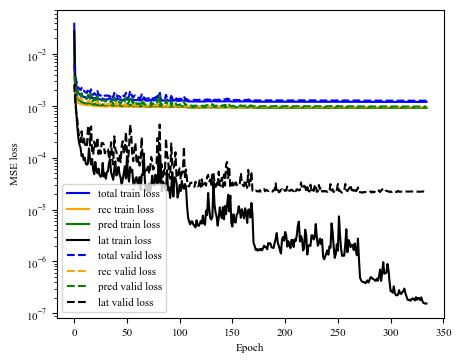

In [5]:
import pickle
import os
import matplotlib.pyplot as plt

# Load history
save_dir = "./results_control_affine"
history_path = os.path.join(save_dir, "history.pkl")
with open(history_path, "rb") as f:
    history = pickle.load(f)

# Plot Learning Curves
fig, axs = plt.subplots(figsize=(5, 4))
axs.set_yscale('log')
axs.set_xlabel('Epoch', fontproperties=times_font)
axs.set_ylabel('MSE loss', fontproperties=times_font)
axs.plot(history['avg_epoch_total_loss_train'], color='blue', linestyle='-', label='total train loss')
axs.plot(history['avg_epoch_rec_loss_train'], color='orange', linestyle='-', label='rec train loss')
axs.plot(history['avg_epoch_pred_loss_train'], color='green', linestyle='-', label='pred train loss')
axs.plot(history['avg_epoch_lat_loss_train'], color='black', linestyle='-', label='lat train loss')

axs.plot(history['epoch_total_loss_valid'], color='blue', linestyle='--', label='total valid loss')
axs.plot(history['epoch_rec_loss_valid'], color='orange', linestyle='--', label='rec valid loss')
axs.plot(history['epoch_pred_loss_valid'], color='green', linestyle='--', label='pred valid loss')
axs.plot(history['epoch_lat_loss_valid'], color='black', linestyle='--', label='lat valid loss')
for label in axs.get_xticklabels():
    label.set_fontproperties(times_font)
for label in axs.get_yticklabels():
    label.set_fontproperties(times_font)
axs.legend(prop=times_font_leg)

### Model Evaluation - Control-affine

To evaluate the trained model, we perform a long-term simulation using initial conditions from the test dataset.

- We select a random trajectory from the test set and extract the initial sequence of states ($X_0$) and the corresponding sequence of control inputs ($U$).
- The model autoregressively predicts future states based on the initial conditions and controls.

In [59]:
# load the model
#model.load_state_dict(torch.load('./results_control_affine/best_model.pth'))

# Evaluate a test simulation
sim_idx = 123
sim_length = 40
init_idx = 0 # randomly chosen initial conditions
test_sim = processed_data['simulations']['test'][sim_idx]

# get initial conditions and controls
X0 = test_sim.states_scaled[0, init_idx:init_idx+lookback]
U = test_sim.controls[0, init_idx:]

# ground truth states
true_states = test_sim.states_scaled[0, init_idx+lookback:init_idx+lookback+sim_length].cpu()
print("True states shape:", true_states.shape)

# simulate 
pred_latents, pred_states = model.simulate(X0, U, sim_length) # Input sequences should not be batched

True states shape: torch.Size([40, 101])


We evalute first the end-to-predicitons of the model:

RMSE: 2.810708


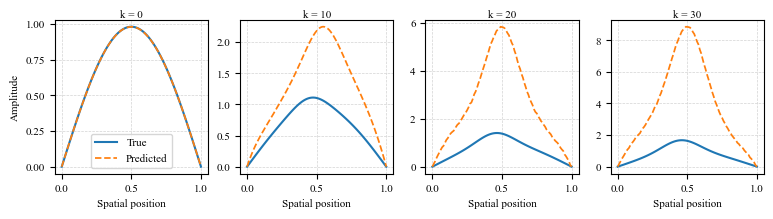

Comparison animation saved to: ./results_control_affine/e2e_comparison.gif


In [128]:
from deepe2erom import animate_compare_1Dsimulations

# Compute RMSE between ground_truth and predicted_dynamics
with torch.no_grad():                                                      # (T-seq, H, W)
    rmse = torch.sqrt(torch.mean((true_states - pred_states) ** 2)).item()
print(f"RMSE: {rmse:.6f}")

# plot multiple snapshots
num_timesteps = 4
fig, axs = plt.subplots(1, num_timesteps, figsize=(9.15, 2), gridspec_kw={'wspace': 0.21, 'hspace': 0.0})
step_size = pred_states.shape[0] // num_timesteps
axs = np.atleast_1d(axs) # type: ignore
for t in range(num_timesteps):
    timestep = t * step_size
    axs[t].plot(np.linspace(0,1,true_states.shape[1]), true_states[timestep], color='C0', label='True')
    axs[t].set_title(r"k = {}".format(timestep), fontproperties=times_font, pad=1)
    axs[t].plot(np.linspace(0,1,pred_states.shape[1]), pred_states[timestep], color='C1', linestyle='--', label='Predicted', linewidth=1.25)
    axs[t].grid(color='lightgray', linestyle='--', linewidth=0.5)
    axs[t].set_xlabel('Spatial position', fontproperties=times_font)
    if t == 0:
        axs[t].set_ylabel('Amplitude', fontproperties=times_font)
        axs[t].legend(prop=times_font_leg)
for ax in axs:
    for label in ax.get_xticklabels() + ax.get_yticklabels():
        label.set_fontproperties(times_font)
fig.savefig("./results_control_affine/state_reconstruction_comparison.pdf", dpi=300, bbox_inches='tight')
plt.show()

# save animation
animate_compare_1Dsimulations(
    true_states,
    pred_states,
    save_path="./results_control_affine/e2e_comparison.gif",
)

Next, we evaluate the control-affine latent dynamics. We consider another trajectory as the one shown above:

True states shape: torch.Size([40, 101])

Latent RMSE (overall): 0.918970
Latent RMSE per-dim: 0.169586, 1.284243, 0.537751, 1.032406, 0.972244, 1.043405


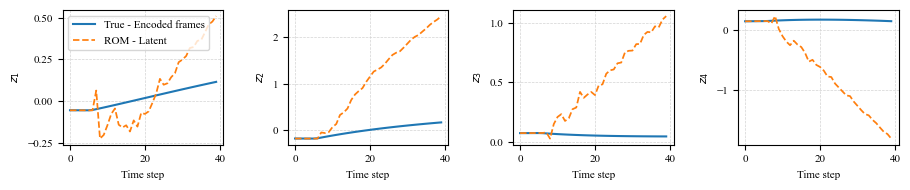

In [138]:
import matplotlib.pyplot as plt

# Evaluate a test simulation
sim_idx = 123
sim_length = 40
init_idx = 0 # randomly chosen initial conditions
test_sim = processed_data['simulations']['test'][sim_idx]

# get initial conditions and controls
X0 = test_sim.states_scaled[0, init_idx:init_idx+lookback]
U = test_sim.controls[0, init_idx:]

# ground truth states
true_states = test_sim.states_scaled[0, init_idx+lookback:init_idx+lookback+sim_length]
print("True states shape:", true_states.shape)

# simulate 
pred_latents, pred_states = model.simulate(X0, U, sim_length) # Input sequences should not be batched

# Get the true latents
model.eval()
with torch.no_grad():
    true_latents = model.encoder(true_states).cpu() # input shape for the encoder (*, nb_channels, height, width)


# Plot latent dynamics comparison
vis_latent = min(4, latent_dim)  # number of latent dimensions to visualize
fig, axs = plt.subplots(1, vis_latent, figsize=(9.15, 2))
axs = np.atleast_1d(axs) # type: ignore
for t in range(vis_latent):
    axs[t].plot(true_latents[:, t], color='C0')
    axs[t].plot(pred_latents[:, t], linestyle='--', color='C1', linewidth=1.25)
    axs[t].set_ylabel(r"$z_{}$".format(t+1), fontproperties=times_font)
    axs[t].set_xlabel('Time step', fontproperties=times_font)
    if t == 0:
        axs[t].legend(['True - Encoded frames', 'ROM - Latent'], prop=times_font_leg)
    axs[t].grid(color='lightgray', linestyle='--', linewidth=0.5)
for ax in axs:
    for label in ax.get_xticklabels() + ax.get_yticklabels():
        label.set_fontproperties(times_font)
plt.tight_layout()
fig.savefig("./results_control_affine/latent_dynamics_comparison.pdf", dpi=300, bbox_inches='tight')
# Compute RMSE
with torch.no_grad():
    diff = pred_latents - true_latents
    latent_rmse_overall = torch.sqrt(torch.mean(diff ** 2)).item()
    latent_rmse_per_dim = torch.sqrt(torch.mean(diff ** 2, dim=0)).detach().cpu()
print(f"\nLatent RMSE (overall): {latent_rmse_overall:.6f}")
print("Latent RMSE per-dim: " + ", ".join([f"{v:.6f}" for v in latent_rmse_per_dim]))

